In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

data_dir = f"{path}/Dataset_BUSI_with_GT"

Path to dataset files: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset


In [5]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    DepthwiseConv2D, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import tensorflow as tf


In [6]:
classes = ['benign','malignant','normal']

images = []
labels = []

for label, cls in enumerate(classes):
    path = os.path.join(data_dir, cls)

    for img in os.listdir(path):

        # Ignore ground truth mask images
        if "mask" in img.lower():
            continue

        img_path = os.path.join(path, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (128,128))

        images.append(image)
        labels.append(label)

images = np.array(images) / 255.0
labels = np.array(labels)

print("Dataset size:", images.shape)

Dataset size: (780, 128, 128, 3)


In [7]:
labels_cat = to_categorical(labels,3)

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    images,
    labels_cat,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [9]:
def create_model():
    """
    CNN using Depthwise Separable Convolutions instead of standard Conv2D.
    Each DSC block = DepthwiseConv2D (spatial filtering) + 1x1 Conv2D (channel mixing).
    This significantly reduces parameters while maintaining representational power.
    """
    model = Sequential()

    # --- Block 1: 32 filters ---
    model.add(DepthwiseConv2D((3,3), padding='same', use_bias=False, input_shape=(128,128,3)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(32, (1,1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2, 2))

    # --- Block 2: 64 filters ---
    model.add(DepthwiseConv2D((3,3), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(64, (1,1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2, 2))

    # --- Block 3: 128 filters ---
    model.add(DepthwiseConv2D((3,3), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Conv2D(128, (1,1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [10]:
model = create_model()

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
I0000 00:00:1775717142.659470      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/15


I0000 00:00:1775717147.751978     122 service.cc:152] XLA service 0x7ead14003440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775717147.752035     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775717148.423827     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775717155.229592     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 ━━━━━━━━━━━━━━━━━━━━ 24s 691ms/step - accuracy: 0.4383 - loss: 25.4090 - val_accuracy: 0.6667 - val_loss: 1.0949
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5003 - loss: 1.0324 - val_accuracy: 0.6667 - val_loss: 1.0952
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5663 - loss: 0.9388 - val_accuracy: 0.1587 - val_loss: 1.0937
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5763 - loss: 0.9360 - val_accuracy: 0.1587 - val_loss: 1.0924
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5943 - loss: 0.9064 - val_accuracy: 0.1587 - val_loss: 1.0914
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5208 - loss: 0.9586 - val_accuracy: 0.1587 - val_loss: 1.0893
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4792 - loss: 0.9786 - val_accuracy: 0.6667 - val_loss: 1.0733
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4956 - loss: 0.9238 - val_accuracy: 0.6667 - val_loss:

In [11]:
def evaluate_model(model,X_test,y_test):

    pred = model.predict(X_test)
    pred_labels = np.argmax(pred,axis=1)
    true_labels = np.argmax(y_test,axis=1)

    acc = accuracy_score(true_labels,pred_labels)
    prec = precision_score(true_labels,pred_labels,average='weighted')
    rec = recall_score(true_labels,pred_labels,average='weighted')
    f1 = f1_score(true_labels,pred_labels,average='weighted')

    return acc,prec,rec,f1

In [12]:
base_results = evaluate_model(model,X_test,y_test)
print("Base CNN:",base_results)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 782ms/step
Base CNN: (0.5576923076923077, 0.31102071005917165, 0.5576923076923077, 0.39933523266856596)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
y_labels = np.argmax(y_train,axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))

In [14]:
model_weights = create_model()

model_weights.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    class_weight=class_weights
)

weights_results = evaluate_model(model_weights,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.3396 - loss: 18.1187
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5200 - loss: 0.9818
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4820 - loss: 0.9276
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4803 - loss: 0.9884
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5498 - loss: 0.9063
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5517 - loss: 0.8234
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5605 - loss: 0.8020
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5127 - loss: 0.8698
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4516 - loss: 0.8413
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4965 - loss: 0.8705
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5034 - loss: 0.8465
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

model_aug = create_model()

model_aug.fit(
    datagen.flow(X_train,y_train,batch_size=32),
    epochs=15
)

aug_results = evaluate_model(model_aug,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 315ms/step - accuracy: 0.4663 - loss: 12.0014
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.5172 - loss: 1.0476
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.4965 - loss: 0.9992
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5858 - loss: 1.0167
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.5627 - loss: 1.0188
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.5493 - loss: 1.0148
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.5685 - loss: 0.9953
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.5958 - loss: 0.9845
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.5562 - loss: 0.9684
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5690 - loss: 0.9790
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.5809 - loss: 0.9749
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/st

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
def focal_loss(gamma=2., alpha=.25):

    def loss(y_true,y_pred):

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred,epsilon,1-epsilon)

        cross_entropy = -y_true*tf.math.log(y_pred)
        weight = alpha*tf.math.pow(1-y_pred,gamma)

        return tf.reduce_sum(weight*cross_entropy,axis=1)

    return loss

In [17]:
model_focal = create_model()

model_focal.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

model_focal.fit(
    X_train,
    y_train,
    epochs=15
)

focal_results = evaluate_model(model_focal,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.4820 - loss: 1.5470
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5686 - loss: 1.7317
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5752 - loss: 1.7110
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5643 - loss: 1.7555
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5842 - loss: 1.6753
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5944 - loss: 1.6339
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5624 - loss: 1.7592
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5473 - loss: 1.8203
Epoch 9/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5467 - loss: 1.8266
Epoch 10/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5487 - loss: 1.8157
Epoch 11/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5653 - loss: 1.7399
Epoch 12/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accurac

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
from imblearn.over_sampling import SMOTE

X_flat = X_train.reshape(len(X_train),-1)
y_labels = np.argmax(y_train,axis=1)

smote = SMOTE()

X_res,y_res = smote.fit_resample(X_flat,y_labels)

X_res = X_res.reshape(-1,128,128,3)
y_res = to_categorical(y_res)

In [19]:
model_smote = create_model()

model_smote.fit(
    X_res,
    y_res,
    epochs=15
)

smote_results = evaluate_model(model_smote,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_depthwise_conv.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - accuracy: 0.3596 - loss: 19.6665
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4524 - loss: 0.9809
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5943 - loss: 0.8105
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6687 - loss: 0.7252
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6694 - loss: 0.7365
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6821 - loss: 0.6567
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6969 - loss: 0.6059
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6670 - loss: 0.6447
Epoch 9/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7199 - loss: 0.6187
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6992 - loss: 0.6171
Epoch 11/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7404 - loss: 0.5333
Epoch 12/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accura

In [20]:
results = pd.DataFrame({
    "Model":[
        "Base CNN",
        "Class Weights",
        "Data Augmentation",
        "Focal Loss",
        "SMOTE"
    ],
    "Accuracy":[
        base_results[0],
        weights_results[0],
        aug_results[0],
        focal_results[0],
        smote_results[0]
    ],
    "Precision":[
        base_results[1],
        weights_results[1],
        aug_results[1],
        focal_results[1],
        smote_results[1]
    ],
    "Recall":[
        base_results[2],
        weights_results[2],
        aug_results[2],
        focal_results[2],
        smote_results[2]
    ],
    "F1 Score":[
        base_results[3],
        weights_results[3],
        aug_results[3],
        focal_results[3],
        smote_results[3]
    ]
})

print(results)

               Model  Accuracy  Precision    Recall  F1 Score
0           Base CNN  0.557692   0.311021  0.557692  0.399335
1      Class Weights  0.269231   0.072485  0.269231  0.114219
2  Data Augmentation  0.557692   0.311021  0.557692  0.399335
3         Focal Loss  0.557692   0.311021  0.557692  0.399335
4              SMOTE  0.512821   0.686945  0.512821  0.492587


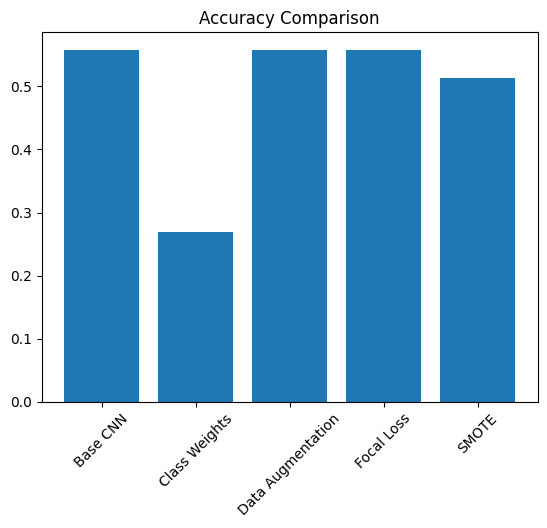

In [21]:
plt.figure()
plt.bar(results["Model"],results["Accuracy"])
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()

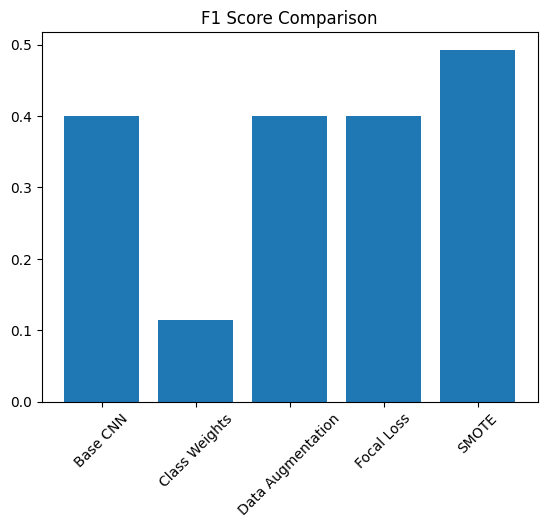

In [22]:
plt.figure()
plt.bar(results["Model"],results["F1 Score"])
plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.show()

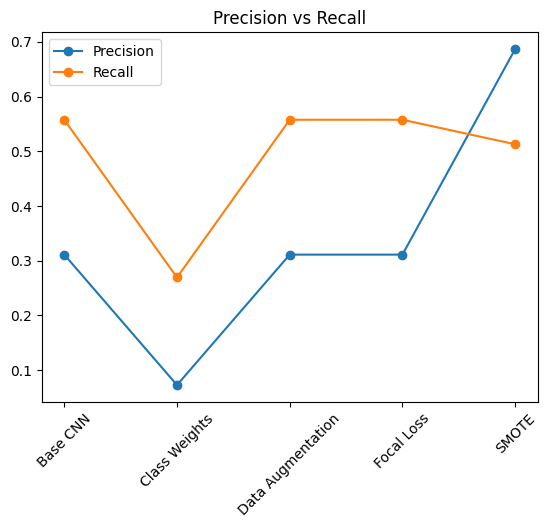

In [23]:
plt.figure()
plt.plot(results["Model"],results["Precision"],marker='o')
plt.plot(results["Model"],results["Recall"],marker='o')
plt.legend(["Precision","Recall"])
plt.xticks(rotation=45)
plt.title("Precision vs Recall")
plt.show()